### Installation of $\kappa$Monty and BHAC and Astrovaria report
This jupyter notebook acts as both a tutorial for validating the KMonty and the radiative code in BHAC with real SgrA* data, as well as a written report for my Astrovaria project for 3EC

#### Installation of $\kappa$Monty

kmonty uses MPI and gsl libraries.

kmonty is compliled with a makefile.

To compile for BHAC use 


In [1]:
mkdir KMcode # can be any name
cd KMcode
git clone https://github.com/oporth/kmonty.git
cd kmonty
git checkout Guru/kmonty-bhac

SyntaxError: invalid syntax (1723054290.py, line 1)

In [ ]:
make bhac

#### Installation of BHAC monte carlo Raditave transfer module

In [ ]:
cd ~
mkdir BHACcode # can be any name
cd BHACcode
git clone git@gitlab.com:BHAC-Developers/bhac-dev.git bhac
git checkout Guru/mc-tet-new

The only thing that should be done after unpacking is to provide the $BHAC_DIR environment variable holding the path to the code. For bash, this can be done by typing:

In [ ]:
export BHAC_DIR=$HOME/codes/bhac

## Report section

### Introduction


SgrA* is a supermassive black hole at the center of the milky way galaxy (Do et al. 2019). Due to an
accreting disk, ~and a relativistic jet~, SgrA* produces a signature electromagnetic spectrum, spanning from
low frequency radio emissions to high energy X-rays and Gamma rays. The exact mechanisms, with which
jets and accretion disk produce their EM emissions is complex and thus details are still debated. This is
why we use both GRMHD and radiative transfer codes in order to theoretical understand these extreme
astrophysical environments better. Right now BHAC is a state-of-art GRMHD code used for modeling
accretion disk of black holes as well as neutron stars. The products of such GRMHD simulations are then
post processed using a radiative transfer code, which is Kappa Monty in this case. Kappa Monty is a
Monty Carlo code used to simulate photon production, trajectories, absorption, and scattering all in strong
magnetic fields like those found in SgrA*. At the moment BHAC and Kappa Monty are two separate codes,
but ideally we want to implement Kappa Monty into the BHAC code base. Not only does this make post
processing easier, but also introduces the possibility for the inclusion of Kappa Monty during the GRMHD
simulation itself. For this project my goal is to validate the new radiative transfer code in BHAC using
Kappa Monty and SgrA* data.

The SgrA* spectrum can be accurately modeled using a disk with a low accretion rate advection dominated accretion flow in its accretion disk. What this means is that density of the disk is low enough
that it is optically thin and radiatively inefficient so that it
can no longer cool effectively via blackbody radiation. This causes the charachteristic spectrum through thermal and non-thermal synchrotron for the low frequencies, compton upscattering from around the $10^{14}-10^{17}$ range, and Brehmsstrahlung for the high frequencies (see next Fig for reference)

<div>
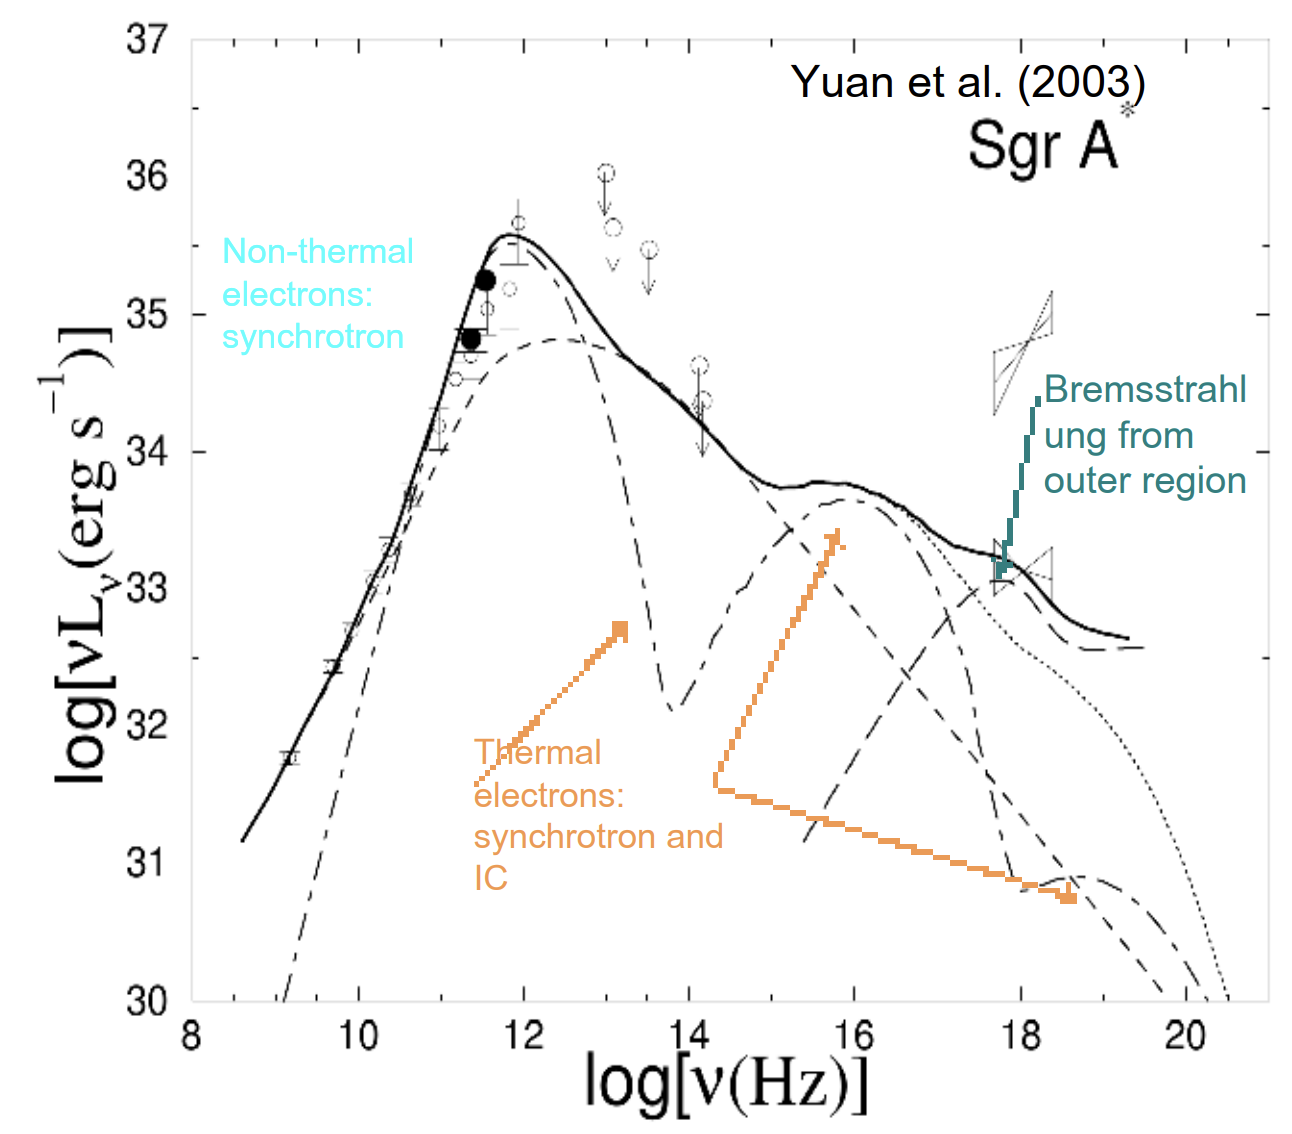
</div>

### Methods

In order to validate the radiative transfer extension of BHAC we compare it to $\kappa$monty, which it is based off of. In this section we will go into detail on how $\kappa$monty recreates the spectrum of SgrA*. 

By inputting data from GRMHD simulations the code traces "superphotons", which are packets representing a number of real photons weighted by a factor w as they propagate through the relativistic plasma. The superphoton distribution is defined as
$\frac{1}{\sqrt{-g}}\frac{dN_s}{d^3x\, dt\, d\nu\, d\Omega} = \frac{1}{w\sqrt{-g}}\frac{dN}{d^3x\, dt\, d\nu\, d\Omega} = \frac{1}{w}\frac{j_\nu}{h\nu}$
where jν​ is the plasma-frame emissivity which can be rwritten as any of three different distribution function in $\kappa$monty: Maxwell Jutnner, Thermal synchrotron, or a power-law. For our case most of the emmision in the range we are interested in is thermal synchrotron emmision. 

Once we have a superphoton distribution the photon trajectories are ray traced by integrating the geodesic equation in Kerr–Schild coordinates, with Christoffel symbols evaluated analytically or via finite differencing of the metric.

$\frac{d^2x^\alpha}{d\lambda^2} = -\Gamma^\alpha_{\mu\nu}\frac{dx^\mu}{d\lambda}\frac{dx^\nu}{d\lambda}$

The next step is scattering; compton scattering is handled stochastically (Dolence et al. 2009). 
When a superphoton is created or scattered, a scattering optical depth is drawn from 
the biased probability distribution $p = 1 - e^{-b\tau_s}$, where $b$ is a bias parameter 
set to enhance sampling of scattered photons in optically thin regions. Two superphotons 
emerge from each event: an unscattered remnant with weight $(1 - 1/b)w$ and a scattered 
superphoton with weight $w/b$, conserving total photon number. The scattered photon energy 
and direction are determined by boosting to the electron rest frame and sampling either the 
Thomson differential cross-section,
\begin{equation}
    \frac{2\pi}{\sigma_T}\frac{d\sigma_T}{d\cos\theta} = \frac{3}{8}(1 + \cos^2\theta),
\end{equation}
for low-energy photons ($\epsilon_e < 10^{-4}$), or the full Klein--Nishina cross-section,
\begin{equation}
    \frac{2\pi}{\sigma_T}\frac{d\sigma_\mathrm{KN}}{d\epsilon'_e} = 
    \frac{1}{2}\frac{\epsilon_e}{\epsilon'^2_e}
    \left[\frac{\epsilon'_e}{\epsilon_e} + \frac{\epsilon_e}{\epsilon'_e} - 1 + \cos^2\theta\right],
\end{equation}
before boosting back to the coordinate frame.

### Results

To verify both the κ\kappa κMONTY code and the BHAC implementation, we compare to the data in ~Yuan et al. (2003)~. In each figure we show only the observed data alongside the different simulation results. Each observational point is referenced by the original paper, as is customary in the literature. The y-axis of each plot shows the luminosity times frequency νLν\nu L_\nu νLν​ in erg/s and the x-axis shows frequency. The κ\kappa κMONTY simulation spectrum is shown as the red dotted line and the grey dashed line shows BHAC.

The first plot is to test whether κ\kappa κMONTY by itself produces a reasonable spectrum. While there are some differences, it is important that the Compton-scattered part of the spectrum is not upscattered to energies above the observed values, which is satisfied here.

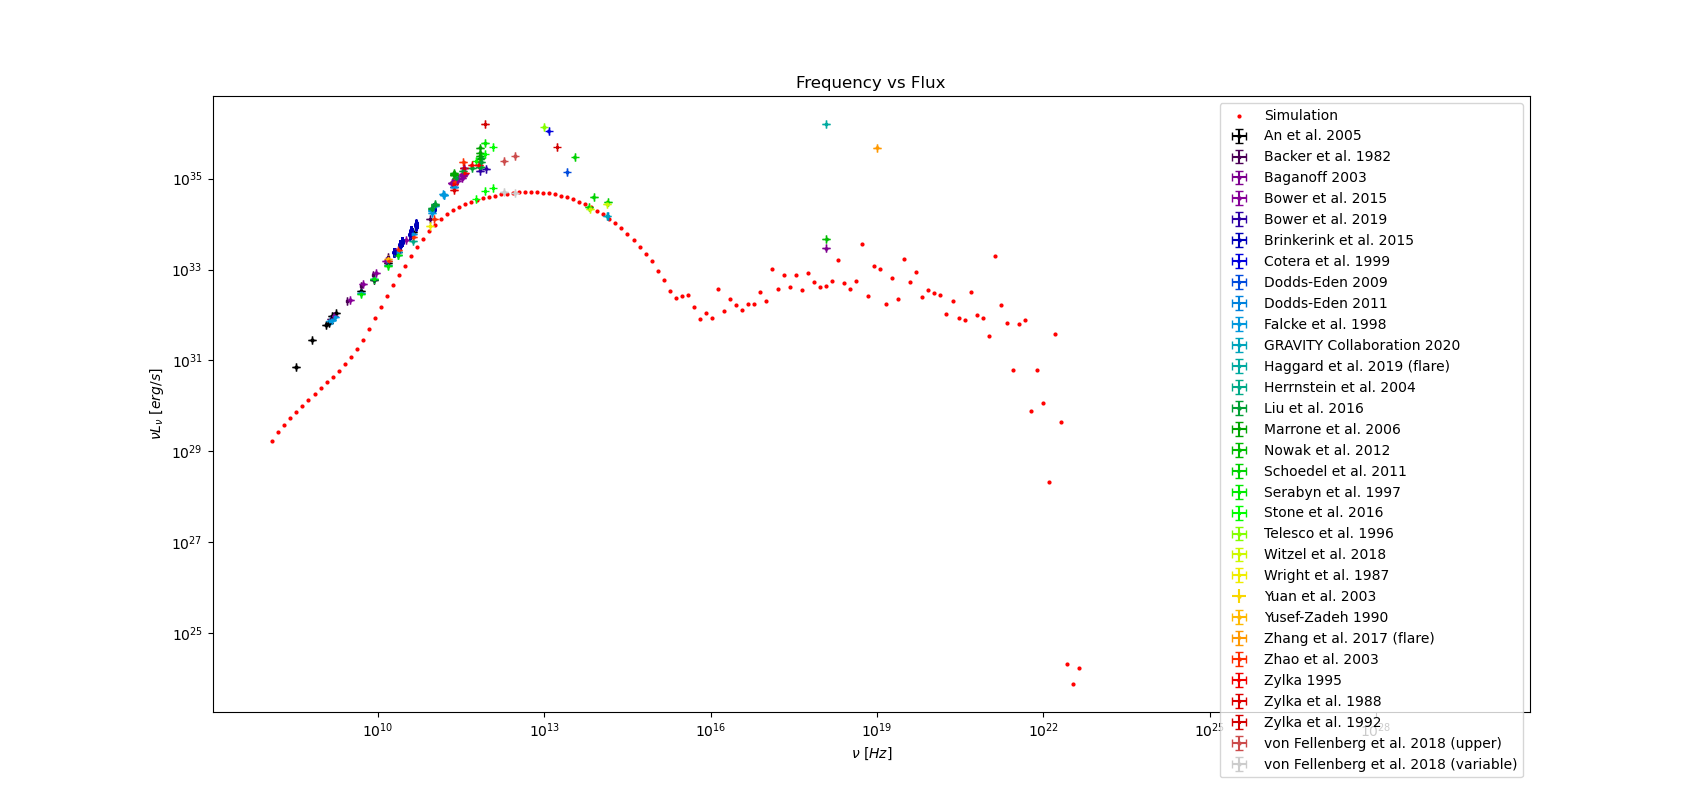


For the following plots, Compton scattering was turned off since at the time of testing the scattering in BHAC was not completely implemented. To ensure that the assumptions made are consistent between both codes, it was important that the electron temperatures as well as parameters such as the accretion rate were matched. Despite this, several orders of magnitude difference remain in many areas of the following plots above ∼1011\sim 10^{11} ∼1011 Hz. The lower frequencies of the κ\kappa κMONTY simulation also show a discrepancy with the data; however, this is to be expected since these energy ranges are dominated by non-thermal synchrotron emission, while we simulate only a thermal synchrotron distribution.

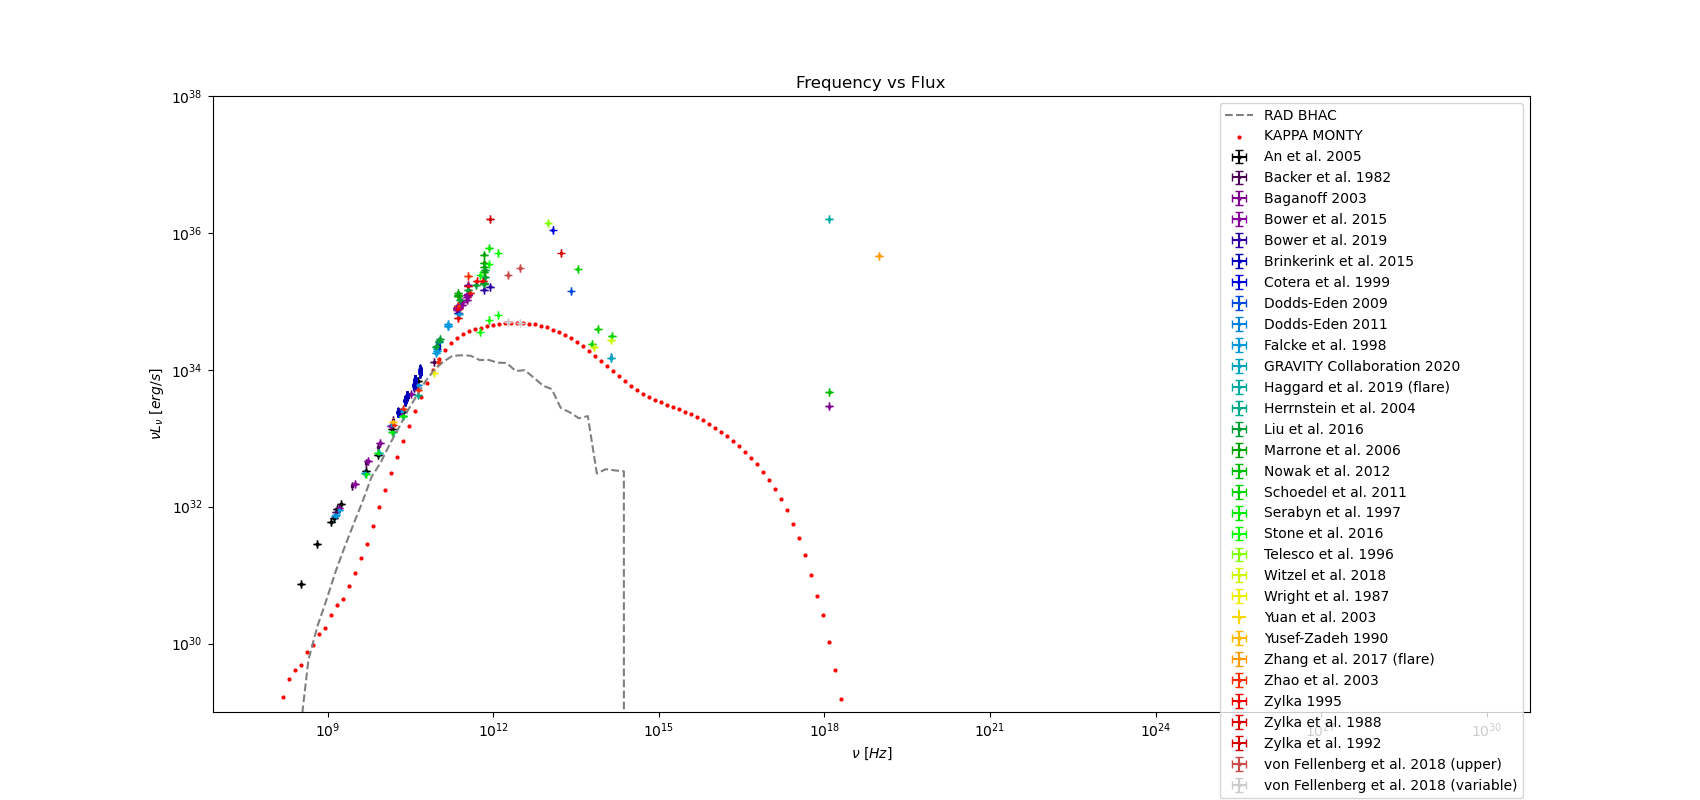

In this plot an additional line is included, showing the spectrum with all θ\theta θ viewing angles taken into account. In the BHAC code all viewing angles were being summed, which was not the case in κ\kappa κMONTY. This was overlooked because BHAC requires more post-processing to produce the spectrum, whereas in κ\kappa κMONTY much of this is handled internally after the simulation. This unfortunately pushes the agreement with BHAC further away, since the κ\kappa κMONTY spectrum now contains more energy.

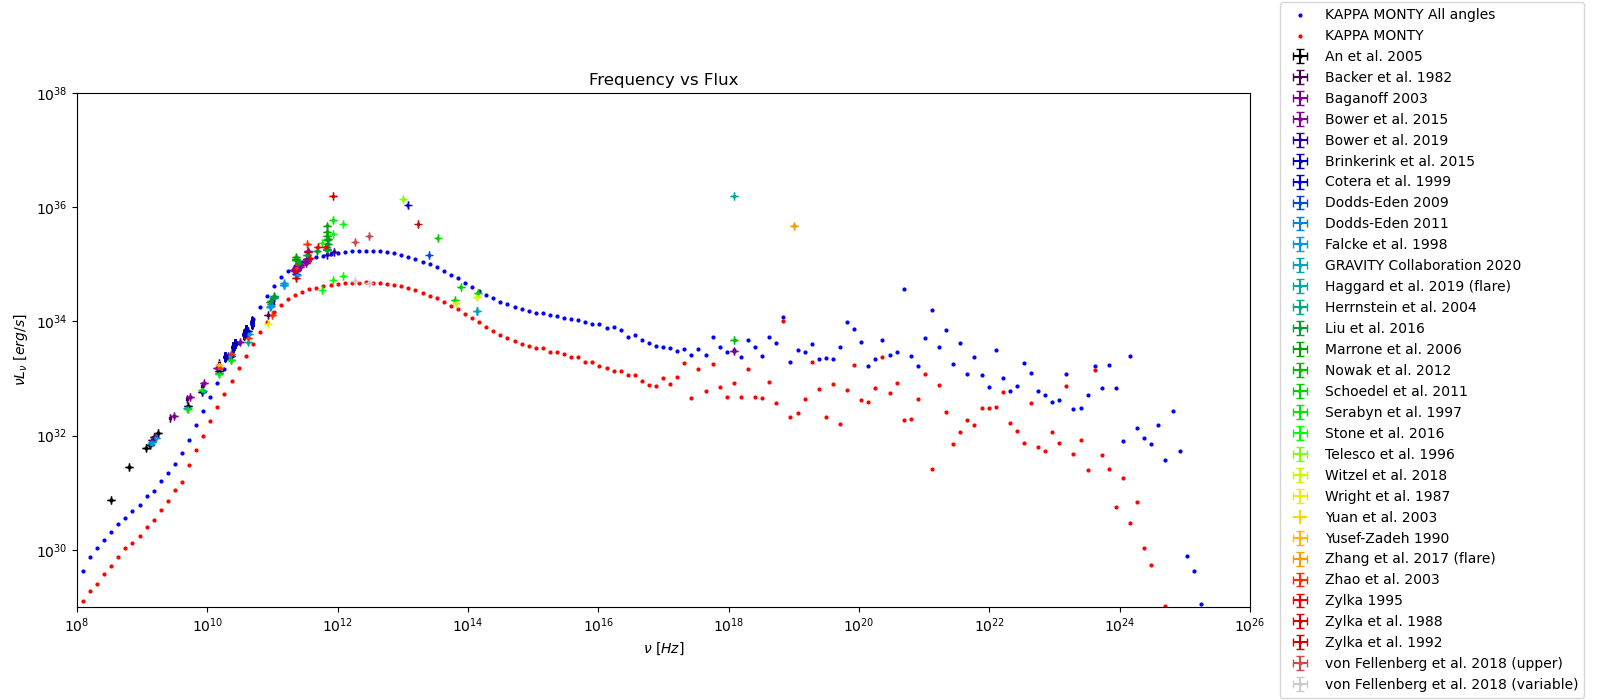

### Conclusion

The goal of this project was to validate the new radiatave BHAC code, for synhcrotron, and compton scattring, using the spectrum to compare to both the known $\kappa$Monty code, as well as SgrA* data. It is quite clear that the BHAC code still needs more iterative work to accurately model astrophysical phenomena like accreting black holes or neutron stars. The compton scattering is being actively developed, but the thermal synchrotron spectrum also needs adjustements. One of the main issues was that when setting the range of the allowed electron temperatures $\Theta$. There is an issues where when the temperature is set to a sufficently low value the photon weights number becomes very large and effectively making the output of the code non-sensical. This massively effects the specturm since a large portion of the energy of the system is in the electrons with temperatures under this arbitrary cutoff. In order to understand what is going wrong and implement fixes can be very time consuming. In the scope of this project this was not feasible due to time constraints. 

### references

Davelaar, J., Ryan, B. R., Wong, G. N., et al. 2023, , 526, 5326 \
Do, T., Hees, A., Ghez, A., et al. 2019, Science, 365, 664 \
Dolence, J. C., Gammie, C. F., Mo´scibrodzka, M., & Leung, P. K. 2009, , 184, 387 \
Event Horizon Telescope Collaboration, Akiyama, K., Alberdi, A., et al. 2022, , 930, L13 \
Scepi, N., Dexter, J., & Begelman, M. C. 2022, , 511, 3536